# Nigeria International Migration Analysis
## Estimated Migration By Age and Sex from 2001 to March 2026

In [1]:
import pandas as pd
filename = 'international-migration-march-2026-estimated-migration-by-age-sex.csv'
df = pd.read_csv(filename)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:")
print(df.head())
print("\nInfo:")
print(df.info())

Shape: (53970, 9)
Columns: ['year_month', 'month_of_release', 'passenger_type', 'direction', 'sex', 'age', 'estimate', 'standard_error', 'status']

Head:
  year_month month_of_release     passenger_type direction     sex        age  \
0    2001-01          2020-09  Long-term migrant  Arrivals  Female  0-4 years   
1    2001-02          2020-09  Long-term migrant  Arrivals  Female  0-4 years   
2    2001-03          2020-09  Long-term migrant  Arrivals  Female  0-4 years   
3    2001-04          2020-09  Long-term migrant  Arrivals  Female  0-4 years   
4    2001-05          2020-09  Long-term migrant  Arrivals  Female  0-4 years   

   estimate  standard_error status  
0       344               0  Final  
1       269               0  Final  
2       239               0  Final  
3       233               0  Final  
4       206               0  Final  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53970 entries, 0 to 53969
Data columns (total 9 columns):
 #   Column           

In [2]:
# Exploration of categorical columns and value ranges
print("Unique passenger_types:", df['passenger_type'].unique())
print("\nUnique directions:", df['direction'].unique())
print("\nUnique sex:", df['sex'].unique())
print("\nUnique age groups:", df['age'].unique())
print("\nUnique status:", df['status'].unique())
print("\nDate range (year_month):", df['year_month'].min(), "to", df['year_month'].max())
print("\nMonth of release unique:")
print(df['month_of_release'].unique())

# Check summary statistics for estimate
print("\nEstimate summary statistics:")
print(df[['estimate', 'standard_error']].describe())

Unique passenger_types: ['Long-term migrant']
Unique directions: ['Arrivals' 'Departures' 'Net']
Unique sex: ['Female' 'Male' 'TOTAL']
Unique age groups: ['0-4 years' '10-14 years' '15-19 years' '20-24 years' '25-29 years'
 '30-34 years' '35-39 years' '40-44 years' '45-49 years' '5-9 years'
 '50-54 years' '55-59 years' '60-64 years' '65-69 years' '70-74 years'
 '75-79 years' '80-84 years' '85-89 years' '90+ years' 'TOTAL']
Unique status: ['Final' 'Provisional']
Date range (year_month): 2001-01 to 2026-03
Month of release unique: ['2020-09' '2020-10' '2020-11' '2020-12' '2021-01' '2021-02' '2021-03'
 '2021-04' '2021-05' '2021-06' '2021-07' '2021-08' '2021-09' '2021-10'
 '2021-11' '2021-12' '2022-01' '2022-02' '2022-03' '2022-04' '2022-05'
 '2022-06' '2022-07' '2022-08' '2022-09' '2022-10' '2022-11' '2022-12'
 '2023-01' '2023-02' '2023-03' '2023-04' '2023-05' '2023-06' '2023-07'
 '2023-08' '2023-09' '2023-10' '2023-11' '2023-12' '2024-01' '2024-02'
 '2024-03' '2024-04' '2024-05' '2024-06

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate totals by year/direction/sex/age
df_total = df[(df['sex'] == 'TOTAL') & (df['age'] == 'TOTAL')]
print("Total rows count:", len(df_total))
print(df_total.groupby('direction')['estimate'].agg(['count', 'sum', 'mean', 'min', 'max']))

# Convert year_month to datetime for trend analysis
df['date'] = pd.to_datetime(df['year_month'])
df_total['date'] = pd.to_datetime(df_total['year_month'])

# Total Migration by Direction over time (annual sum)
df_total['year'] = df_total['date'].dt.year
annual_dir = df_total.groupby(['year', 'direction'])['estimate'].sum().unstack()
print("\nAnnual Migration Totals (Recent Years):")
print(annual_dir.tail(10))

# Age breakdown (excluding TOTAL age and TOTAL sex, or sex=='TOTAL')
df_age = df[(df['sex'] == 'TOTAL') & (df['age'] != 'TOTAL')]
age_totals = df_age.groupby(['age', 'direction'])['estimate'].sum().unstack()
print("\nTotal Migration by Age Group across entire period:")
print(age_totals.sort_values(by='Arrivals', ascending=False))

Total rows count: 909
            count      sum          mean   min    max
direction                                            
Arrivals      303  3107472  10255.683168  1135  24931
Departures    303  2328047   7683.323432  1008  12700
Net           303   779428   2572.369637 -4451  16628

Annual Migration Totals (Recent Years):
direction  Arrivals  Departures     Net
year                                   
2017         140102       86822   53280
2018         139014       89447   49567
2019         165742       93154   72588
2020          91444       54600   36844
2021          55459       70409  -14950
2022         119440       94541   24899
2023         229893      101940  127953
2024         142434      118683   23751
2025         131960      115384   16577
2026          38698       26522   12178

Total Migration by Age Group across entire period:
direction    Arrivals  Departures     Net
age                                      
25-29 years    522739      413091  109650
20-24 yea

C:\Users\Admin\AppData\Local\Temp\ipykernel_5460\4181722291.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['date'] = pd.to_datetime(df_total['year_month'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_5460\4181722291.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['year'] = df_total['date'].dt.year


In [4]:
print("=== Direction Totals (where sex=TOTAL, age=TOTAL) ===")
print(df_total.groupby('direction')['estimate'].agg(['count', 'sum', 'mean', 'min', 'max']))

print("\n=== Annual Migration Totals (2015 - 2026) ===")
print(annual_dir.loc[2015:])

print("\n=== Top Age Groups (Arrivals, Departures, Net) ===")
print(age_totals.sort_values(by='Arrivals', ascending=False))

=== Direction Totals (where sex=TOTAL, age=TOTAL) ===
            count      sum          mean   min    max
direction                                            
Arrivals      303  3107472  10255.683168  1135  24931
Departures    303  2328047   7683.323432  1008  12700
Net           303   779428   2572.369637 -4451  16628

=== Annual Migration Totals (2015 - 2026) ===
direction  Arrivals  Departures     Net
year                                   
2015         140125       80316   59809
2016         143124       80235   62889
2017         140102       86822   53280
2018         139014       89447   49567
2019         165742       93154   72588
2020          91444       54600   36844
2021          55459       70409  -14950
2022         119440       94541   24899
2023         229893      101940  127953
2024         142434      118683   23751
2025         131960      115384   16577
2026          38698       26522   12178

=== Top Age Groups (Arrivals, Departures, Net) ===
direction    Arri

In [5]:
df_sex = df[(df['sex'] != 'TOTAL') & (df['age'] == 'TOTAL')]
sex_totals = df_sex.groupby(['sex', 'direction'])['estimate'].sum().unstack()
print("=== Totals by Sex (Entire Period 2001-2026) ===")
print(sex_totals)

# Sex totals by recent year
annual_sex = df_sex.groupby(['sex', 'direction'])['estimate'].sum().unstack()
print(df_sex.groupby(['sex', 'direction'])['estimate'].agg(['count', 'sum', 'mean']))

=== Totals by Sex (Entire Period 2001-2026) ===
direction  Arrivals  Departures     Net
sex                                    
Female      1518979     1122599  396381
Male        1588497     1205446  383047
                   count      sum         mean
sex    direction                              
Female Arrivals      303  1518979  5013.132013
       Departures    303  1122599  3704.947195
       Net           303   396381  1308.188119
Male   Arrivals      303  1588497  5242.564356
       Departures    303  1205446  3978.369637
       Net           303   383047  1264.181518


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('international-migration-march-2026-estimated-migration-by-age-sex.csv')
df['date'] = pd.to_datetime(df['year_month'])
df['year'] = df['date'].dt.year

In [7]:
# 2. Filter aggregated totals (Sex = TOTAL, Age = TOTAL)
df_total = df[(df['sex'] == 'TOTAL') & (df['age'] == 'TOTAL')]

# Summary statistics by direction
overall_summary = df_total.groupby('direction')['estimate'].agg(
    Total_Count='sum',
    Monthly_Mean='mean',
    Min='min',
    Max='max'
)
print("=== Overall Summary (2001 - 2026) ===")
print(overall_summary)

=== Overall Summary (2001 - 2026) ===
            Total_Count  Monthly_Mean   Min    Max
direction                                         
Arrivals        3107472  10255.683168  1135  24931
Departures      2328047   7683.323432  1008  12700
Net              779428   2572.369637 -4451  16628


In [8]:
# 3. Annual Trends (Arrivals vs Departures vs Net)
annual_trends = df_total.groupby(['year', 'direction'])['estimate'].sum().unstack()
print("\n=== Annual Migration (Recent 10 Years) ===")
print(annual_trends.tail(10))


=== Annual Migration (Recent 10 Years) ===
direction  Arrivals  Departures     Net
year                                   
2017         140102       86822   53280
2018         139014       89447   49567
2019         165742       93154   72588
2020          91444       54600   36844
2021          55459       70409  -14950
2022         119440       94541   24899
2023         229893      101940  127953
2024         142434      118683   23751
2025         131960      115384   16577
2026          38698       26522   12178


In [9]:
# 4. Age Group Analysis (excluding TOTAL aggregates)
df_age = df[(df['sex'] == 'TOTAL') & (df['age'] != 'TOTAL')]
age_summary = df_age.groupby(['age', 'direction'])['estimate'].sum().unstack()
age_summary['Net'] = age_summary['Arrivals'] - age_summary['Departures']
print("\n=== Top Age Groups by Net Migration ===")
print(age_summary.sort_values(by='Net', ascending=False).head(5))


=== Top Age Groups by Net Migration ===
direction    Arrivals  Departures     Net
age                                      
30-34 years    395295      258996  136299
25-29 years    522739      413091  109648
15-19 years    263159      161310  101849
35-39 years    280335      181342   98993
10-14 years    171930      107016   64914


In [10]:
# 5. Sex Distribution Analysis
df_sex = df[(df['sex'] != 'TOTAL') & (df['age'] == 'TOTAL')]
sex_summary = df_sex.groupby(['sex', 'direction'])['estimate'].sum().unstack()
print("\n=== Migration by Sex ===")
print(sex_summary)


=== Migration by Sex ===
direction  Arrivals  Departures     Net
sex                                    
Female      1518979     1122599  396381
Male        1588497     1205446  383047


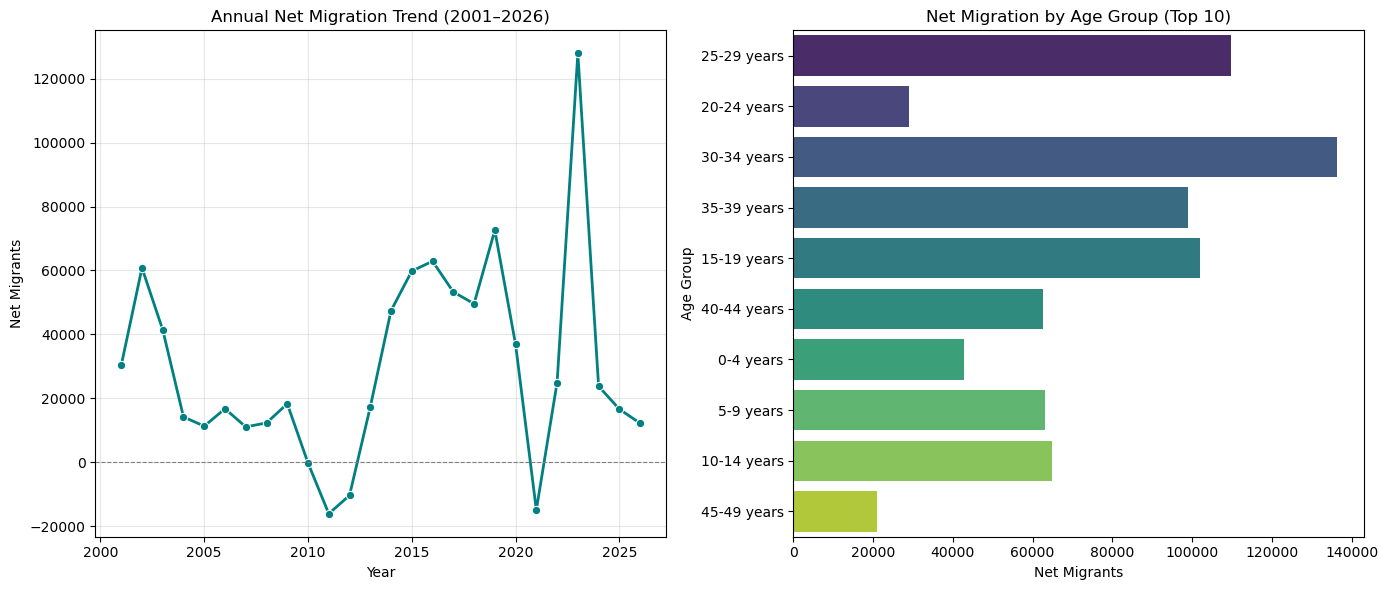

In [11]:
# 6. Visualization: Annual Migration Trends & Age Breakdown
plt.figure(figsize=(14, 6))

# Plot 1: Annual Net Migration Trend
plt.subplot(1, 2, 1)
sns.lineplot(data=annual_trends, x=annual_trends.index, y='Net', marker='o', color='teal', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Annual Net Migration Trend (2001–2026)')
plt.xlabel('Year')
plt.ylabel('Net Migrants')
plt.grid(True, alpha=0.3)

# Plot 2: Top 10 Age Groups Net Migration
plt.subplot(1, 2, 2)
top_ages = age_summary.sort_values(by='Arrivals', ascending=False).head(10)
sns.barplot(x=top_ages['Net'], y=top_ages.index, palette='viridis')
plt.title('Net Migration by Age Group (Top 10)')
plt.xlabel('Net Migrants')
plt.ylabel('Age Group')

plt.tight_layout()
plt.show()

### Key Demographic & Trend Insights

* Dominant Age Groups: Young adults aged 20–34 make up the largest share of long-term migration. The 25–29 age group leads total arrivals (522,739), while the 30–34 group yields the highest net gain (+136,299).

* Sex Distribution: Male arrivals slightly outnumber female arrivals (51.1% male vs. 48.9% female), but female net migration (+396,381) is slightly higher overall due to lower female departure rates (+383,047 male net).

* Pandemic Impact (2021): 2021 recorded a net loss (-14,950) due to COVID-19 border restrictions and elevated departures.

* Post-Pandemic Peak (2023): 2023 experienced a massive rebound, reaching a net gain peak of +127,953 (229,893 arrivals vs. 101,940 departures).